In [1]:
# Cell 1: imports + load package

import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import welch, coherence, csd

data = np.load("./data/full_analysis_package.npz")

source = data["source"]
source_rep = data["source_rep"]

error = data["error"]
ref = data["ref"]

error_nc = data["error_nc"]
ref_nc = data["ref_nc"]

w_norm_log = data["w_norm_log"]
weights = data["weights"]

error_ir = data["error_ir"]
ref_ir = data["ref_ir"]

error_ir_raw = data["error_ir_raw"]
ref_ir_raw = data["ref_ir_raw"]

fs = float(data["fs"])

mu = float(data["mu"])
cancel_gain = float(data["cancel_gain"])
leak = float(data["leak"])
lag = int(data["lag"])
eps = float(data["eps"])

ref_threshold = float(data["ref_threshold"])
mavg_tau_ms = float(data["mavg_tau_ms"])
update_sign = float(data["update_sign"])

max_step = float(data["max_step"])
min_xnorm = float(data["min_xnorm"])
max_control = float(data["max_control"])

n_repeats = int(data["n_repeats"])
ir_len = int(data["ir_len"])
panel_to_error_cm = float(data["panel_to_error_cm"])

print(f"fs = {fs:.0f} Hz")
print(f"weights = {len(weights)} taps")
print(f"IR length = {ir_len}")
print(f"lag = {lag}")
print(f"cancel_gain = {cancel_gain}")
print(f"mu = {mu}")
print(f"leak = {leak}")
print(f"max_control = {max_control}")

fs = 96000 Hz
weights = 1024 taps
IR length = 256
lag = 86
cancel_gain = 0.11
mu = 0.00325
leak = 1e-06
max_control = 0.0471411


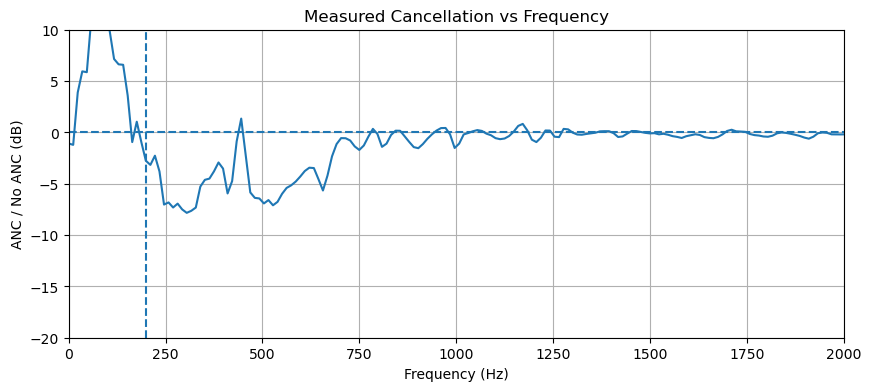

In [2]:
# Cell 2: measured cancellation vs frequency

NPERSEG = 8192

f, P_cancel = welch(
    error,
    fs=fs,
    nperseg=NPERSEG,
)

_, P_no_cancel = welch(
    error_nc,
    fs=fs,
    nperseg=NPERSEG,
)

reduction_db = 10 * np.log10(
    (P_cancel + 1e-30) /
    (P_no_cancel + 1e-30)
)

plt.figure(figsize=(10, 4))

plt.plot(f, reduction_db)

plt.axhline(0, linestyle="--")
plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-20, 10)

plt.xlabel("Frequency (Hz)")
plt.ylabel("ANC / No ANC (dB)")
plt.title("Measured Cancellation vs Frequency")
plt.grid()

plt.show()

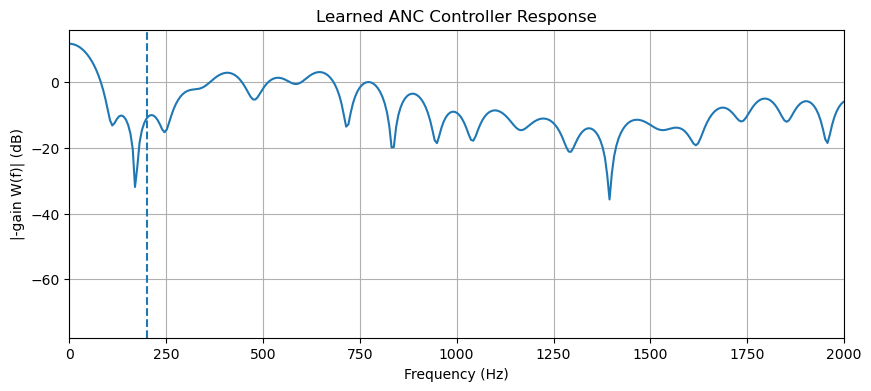

In [3]:
# Cell 3: learned controller frequency response

NFFT = 16384

f_fft = np.fft.rfftfreq(NFFT, 1 / fs)

W = np.fft.rfft(weights, n=NFFT)

W_control = -cancel_gain * W

W_db = 20 * np.log10(
    np.abs(W_control) + 1e-30
)

plt.figure(figsize=(10, 4))

plt.plot(f_fft, W_db)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("|-gain W(f)| (dB)")
plt.title("Learned ANC Controller Response")
plt.grid()

plt.show()

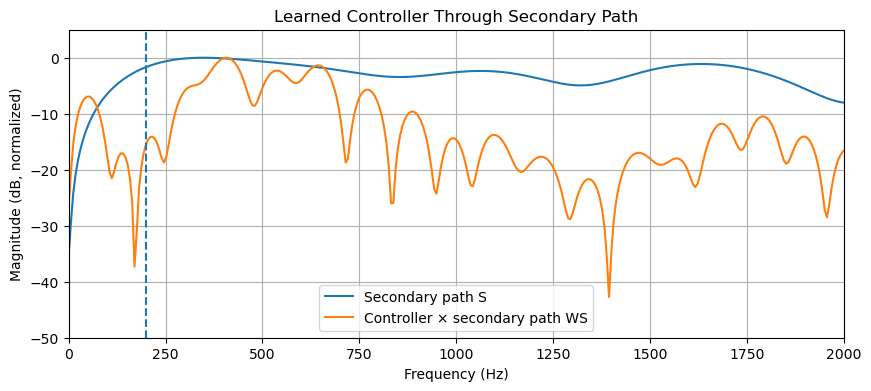

In [4]:
# Cell 4: controller after secondary path

S = np.fft.rfft(error_ir, n=NFFT)

WS = W_control * S

S_db = 20 * np.log10(
    np.abs(S) + 1e-30
)

WS_db = 20 * np.log10(
    np.abs(WS) + 1e-30
)

# Normalize separately for shape comparison
S_db_norm = S_db - np.max(S_db)
WS_db_norm = WS_db - np.max(WS_db)

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    S_db_norm,
    label="Secondary path S"
)

plt.plot(
    f_fft,
    WS_db_norm,
    label="Controller × secondary path WS"
)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-50, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB, normalized)")
plt.title("Learned Controller Through Secondary Path")
plt.grid()
plt.legend()

plt.show()

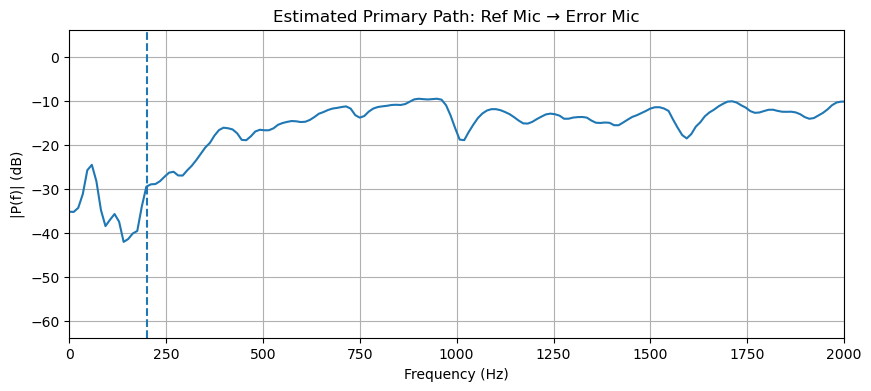

In [5]:
# Cell 5: estimate primary path, ref mic -> error mic

f_tf, S_er = csd(
    error_nc,
    ref_nc,
    fs=fs,
    nperseg=NPERSEG,
)

_, S_rr = welch(
    ref_nc,
    fs=fs,
    nperseg=NPERSEG,
)

P_est = S_er / (S_rr + 1e-30)

P_db = 20 * np.log10(
    np.abs(P_est) + 1e-30
)

plt.figure(figsize=(10, 4))

plt.plot(f_tf, P_db)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)

plt.xlabel("Frequency (Hz)")
plt.ylabel("|P(f)| (dB)")
plt.title("Estimated Primary Path: Ref Mic → Error Mic")
plt.grid()

plt.show()

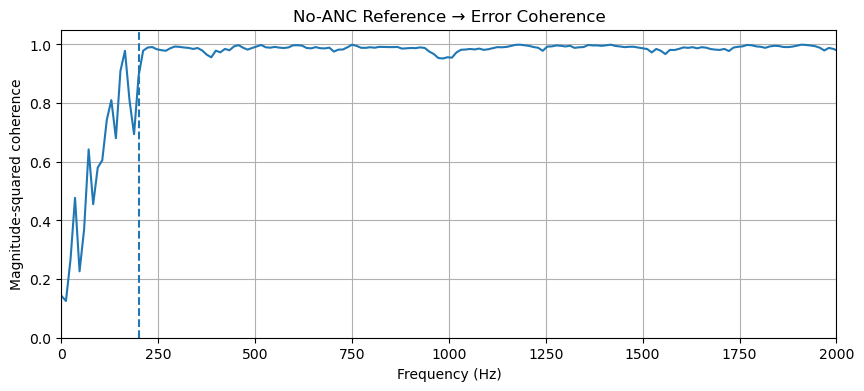

In [6]:
# Cell 6: ref-mic -> error-mic coherence

f_coh, coh = coherence(
    ref_nc,
    error_nc,
    fs=fs,
    nperseg=NPERSEG,
)

plt.figure(figsize=(10, 4))

plt.plot(f_coh, coh)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(0, 1.05)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude-squared coherence")
plt.title("No-ANC Reference → Error Coherence")
plt.grid()

plt.show()

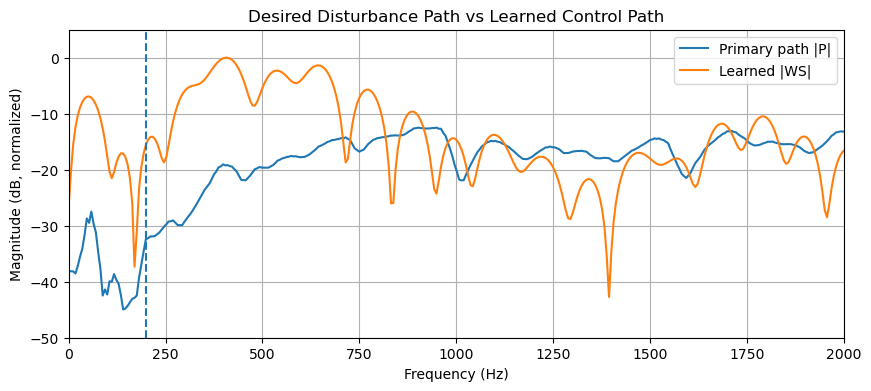

In [7]:
# Cell 7: compare desired primary cancellation shape vs learned WS

# Interpolate P_est onto FFT frequency grid
P_interp_real = np.interp(
    f_fft,
    f_tf,
    np.real(P_est)
)

P_interp_imag = np.interp(
    f_fft,
    f_tf,
    np.imag(P_est)
)

P_interp = P_interp_real + 1j * P_interp_imag

P_mag_db = 20 * np.log10(
    np.abs(P_interp) + 1e-30
)

WS_mag_db = 20 * np.log10(
    np.abs(WS) + 1e-30
)

# normalize for shape comparison
P_mag_db_norm = P_mag_db - np.max(P_mag_db)
WS_mag_db_norm = WS_mag_db - np.max(WS_mag_db)

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    P_mag_db_norm,
    label="Primary path |P|"
)

plt.plot(
    f_fft,
    WS_mag_db_norm,
    label="Learned |WS|"
)

plt.axvline(200, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-50, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB, normalized)")
plt.title("Desired Disturbance Path vs Learned Control Path")
plt.grid()
plt.legend()

plt.show()

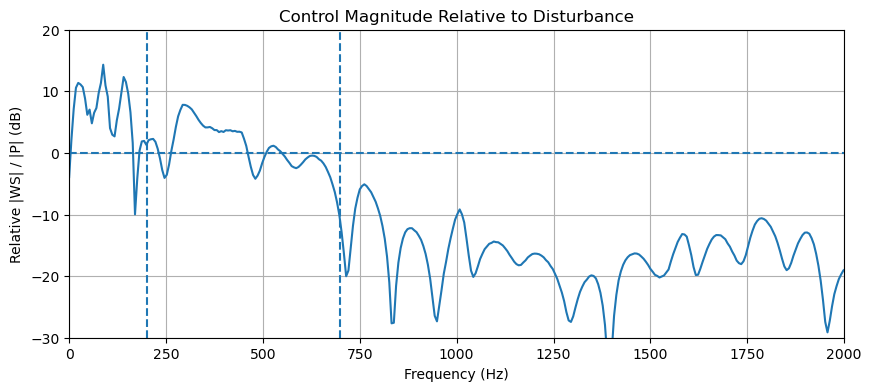

In [8]:
# Cell 8: relative control magnitude vs disturbance

mag_ratio_db = 20 * np.log10(
    (np.abs(WS) + 1e-30) /
    (np.abs(P_interp) + 1e-30)
)

# Normalize using median ratio in successful ANC band
good_band = (
    (f_fft >= 300) &
    (f_fft <= 700)
)

offset = np.median(
    mag_ratio_db[good_band]
)

mag_ratio_db_rel = mag_ratio_db - offset

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    mag_ratio_db_rel
)

plt.axhline(0, linestyle="--")
plt.axvline(200, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-30, 20)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative |WS| / |P| (dB)")
plt.title("Control Magnitude Relative to Disturbance")
plt.grid()

plt.show()

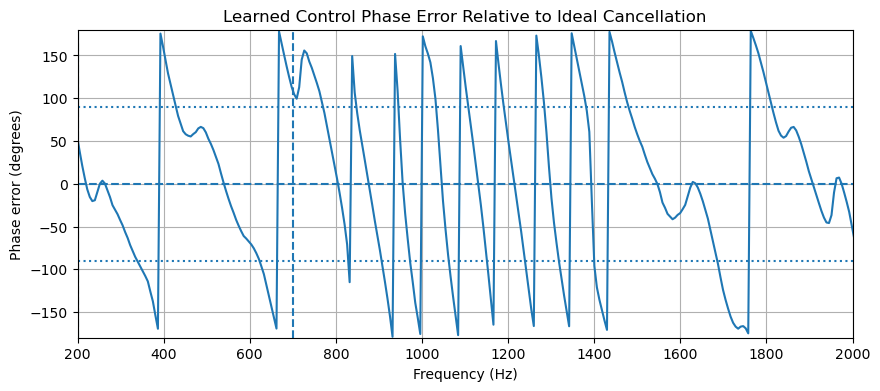

In [9]:
# Cell 9: controller phase error relative to ideal cancellation

phase_error = np.angle(
    WS / (-P_interp + 1e-30)
)

phase_error_deg = np.degrees(
    phase_error
)

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    phase_error_deg
)

plt.axhline(0, linestyle="--")
plt.axhline(90, linestyle=":")
plt.axhline(-90, linestyle=":")

plt.axvline(200, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(200, 2000)
plt.ylim(-180, 180)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase error (degrees)")
plt.title("Learned Control Phase Error Relative to Ideal Cancellation")
plt.grid()

plt.show()

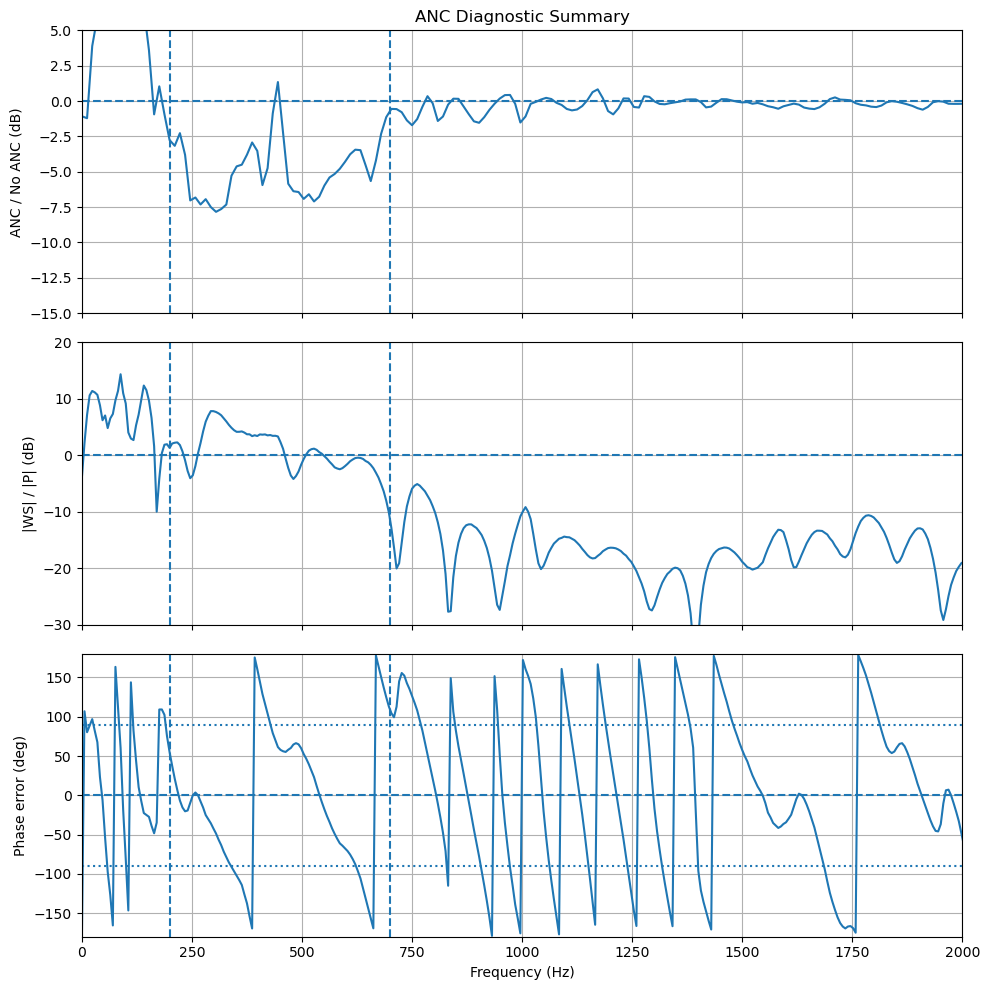

In [10]:
# Cell 10: combined diagnostic

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 10),
    sharex=True
)

# measured cancellation
axes[0].plot(
    f,
    reduction_db
)

axes[0].axhline(0, linestyle="--")
axes[0].set_ylabel("ANC / No ANC (dB)")
axes[0].set_ylim(-15, 5)
axes[0].grid()
axes[0].set_title("ANC Diagnostic Summary")

# relative magnitude
axes[1].plot(
    f_fft,
    mag_ratio_db_rel
)

axes[1].axhline(0, linestyle="--")
axes[1].set_ylabel("|WS| / |P| (dB)")
axes[1].set_ylim(-30, 20)
axes[1].grid()

# phase error
axes[2].plot(
    f_fft,
    phase_error_deg
)

axes[2].axhline(0, linestyle="--")
axes[2].axhline(90, linestyle=":")
axes[2].axhline(-90, linestyle=":")

axes[2].set_ylabel("Phase error (deg)")
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylim(-180, 180)
axes[2].grid()

for ax in axes:
    ax.axvline(200, linestyle="--")
    ax.axvline(700, linestyle="--")
    ax.set_xlim(0, 2000)

plt.tight_layout()
plt.show()

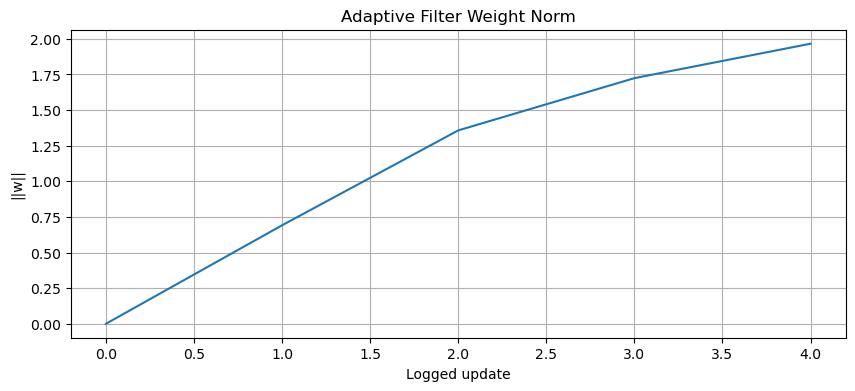

In [11]:
# Cell 11: weight norm evolution

plt.figure(figsize=(10, 4))

plt.plot(w_norm_log)

plt.xlabel("Logged update")
plt.ylabel("||w||")
plt.title("Adaptive Filter Weight Norm")
plt.grid()

plt.show()

In [1]:
from scipy.signal import welch, fftconvolve
import numpy as np
import matplotlib.pyplot as plt

# Use no-ANC reference so there is no controller feedback contaminating it
xf_nc = fftconvolve(ref_nc, error_ir, mode="full")[:len(ref_nc)]

f_xf, P_xf = welch(
    xf_nc,
    fs=fs,
    nperseg=8192,
)

P_xf_db = 10 * np.log10(P_xf + 1e-30)
P_xf_db -= np.max(P_xf_db)

plt.figure(figsize=(10, 4))
plt.plot(f_xf, P_xf_db)

plt.axvline(200, linestyle="--", c='r')
plt.axvline(700, linestyle="--", c='r')

plt.xlim(0, 2000)
plt.ylim(-60, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Filtered-reference PSD (dB, normalized)")
plt.title("FxLMS Gradient Excitation vs Frequency")
plt.grid()
plt.show()

NameError: name 'ref_nc' is not defined

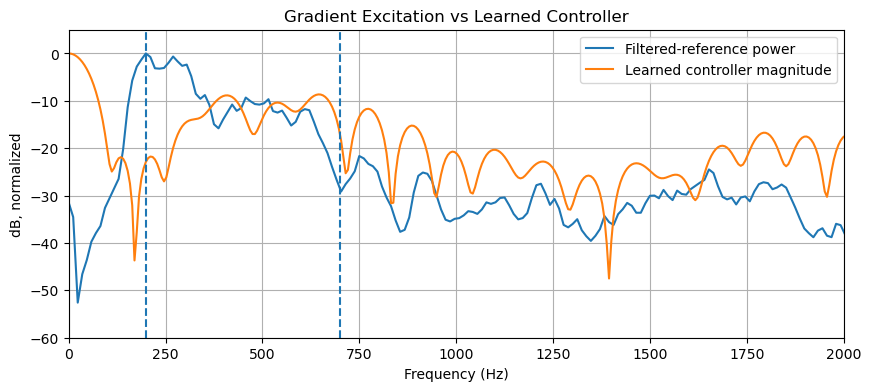

In [13]:
# interpolate filtered-reference PSD onto FFT frequencies
P_xf_interp = np.interp(
    f_fft,
    f_xf,
    P_xf_db,
)

W_plot = 20 * np.log10(np.abs(W_control) + 1e-30)
W_plot -= np.max(W_plot)

plt.figure(figsize=(10, 4))

plt.plot(
    f_fft,
    P_xf_interp,
    label="Filtered-reference power"
)

plt.plot(
    f_fft,
    W_plot,
    label="Learned controller magnitude"
)

plt.axvline(200, linestyle="--")
plt.axvline(700, linestyle="--")

plt.xlim(0, 2000)
plt.ylim(-60, 5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("dB, normalized")
plt.title("Gradient Excitation vs Learned Controller")
plt.grid()
plt.legend()
plt.show()